In [35]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [37]:
def LDU(A):
    A = np.array(A)
    r,c = A.shape
    L = np.zeros((r,c))
    D = np.zeros((r, c))
    U = np.zeros((r, c))
    for i in range(r):
        for j in range(c):
            if i == j:
                D[i][j] = A[i][j]
            elif i > j:
                L[i][j] = A[i][j]
            else:  # i < j
                U[i][j] = A[i][j]
    return L,D,U

In [39]:
def sor(A, b, omega):
    n = len(b)
    x = np.zeros(n)
    tol = 1e-8
    max_iter = 10000
    start = time.time()
    for k in range(max_iter):
        x_new = x.copy()
        for i in range(n):
            sum1 = np.dot(A[i, :i], x_new[:i])
            sum2 = np.dot(A[i, i+1:], x[i+1:])
            x_new[i] = (1 - omega) * x[i] + (omega / A[i, i]) * (b[i] - sum1 - sum2)
        if np.linalg.norm(x_new - x, np.inf) < tol:
            end = time.time()
            return x_new, k + 1, end - start
        x = x_new.copy()
    end = time.time()
    print("SOR did not converge within", max_iter, "iterations")
    return x, max_iter, end - start


## 1A

In [42]:
def matrix_maker(n):
    n2 = n ** 2
    A = (np.diag(4 * np.ones(n2))- np.diag(np.ones(n2 - 1), k=-1)- np.diag(np.ones(n2 - 1), k=1)- np.diag(np.ones(n2 - n), k=-n) 
         - np.diag(np.ones(n2 - n), k=n))
    return A

In [44]:
n_values = [3, 5, 8, 10]
omega_values = np.linspace(1.0, 1.8, 25)  # 25 points between 1.0 and 1.8
results = {}

for n in n_values:
    A = matrix_maker(n)
    x_true = np.ones(n**2)
    b = A @ x_true
    it_counts = []

    for omega in omega_values:
        _, it, func_time = sor(A, b, omega)
        it_counts.append(it)

    results[n] = it_counts

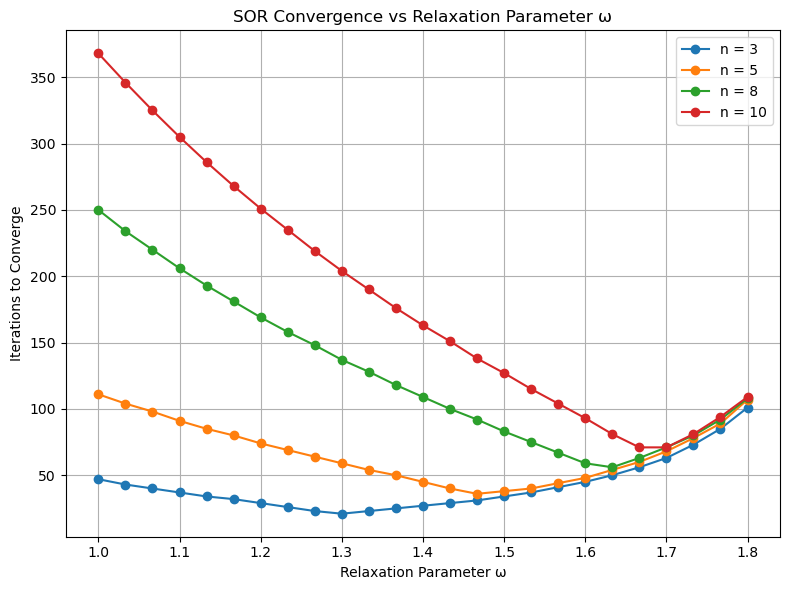

In [45]:
plt.figure(figsize=(8,6))
for n in n_values:
    plt.plot(omega_values, results[n], marker='o', label=f'n = {n}')

plt.title('SOR Convergence vs Relaxation Parameter ω')
plt.xlabel('Relaxation Parameter ω')
plt.ylabel('Iterations to Converge')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
for n in n_values:
    best_idx = np.argmin(results[n])
    print(f"For n = {n}, optimal ω = {omega_values[best_idx]:.3f}, "
          f"iterations = {results[n][best_idx]}")

For n = 3, optimal ω = 1.300, iterations = 21
For n = 5, optimal ω = 1.467, iterations = 36
For n = 8, optimal ω = 1.633, iterations = 56
For n = 10, optimal ω = 1.667, iterations = 71


There seems to be a parabolic curve when trying to achieve the optimal omega if omega keeps increasing. What this also tells us is that if we want to use whole numbers for omega, the best to use would be 1 as it is the closest value that converges for each n value.

## 1b

In [77]:
def conjgrad (A , b , x0 , tol ) :
    n = A . shape [0] # get the size of A
    max_i = 1000 # set max_i
    i = 0 # iteration counter
    r = b - A @ x0 # initial residual
    p = r . copy () # initial search direction
    x = x0 . copy ()
    err = np . linalg . norm (r , 2)
    start = time.time()
    while err > tol :
        i += 1 # increment iteration counte
        if i > max_i :
            print (f" CG did not converge after {i:g} iterations" )
            break
        rnorm = err # previous residual norm
        w = A @ p # compute w
        alpha = rnorm **2 / ( p . dot ( w ) ) # compute alpha
        x += alpha * p # form next iterate
        r -= alpha * w # form the new residual
        err = np . linalg . norm (r , 2) # norm of new residual
        beta = err **2 / rnorm **2 # compute beta
        p = r + beta * p # compute new search direction
    end = time.time()  # stop timer
    runtime = end - start
    if i <= max_i :
        print (f"CG converged in {i:g} iterations with residual norm of {err:g}")
    return x , i , runtime

In [79]:
n_values = np.arange(10, 81, 10)
iters = []
runtimes = []
for n in n_values:
    A = matrix_maker(n)
    n2 = n ** 2
    b = A @ np.ones(n2)
    x0 = np.zeros(n2)

    x, num_iter, runtime = conjgrad(A, b, x0, tol = 1e-8)

    iters.append(num_iter)
    runtimes.append(runtime)
    print(f"n={n:2d}, size={n2:4d}, iterations={num_iter:3d}, time={runtime:.4f}s")

CG converged in 32 iterations with residual norm of 5.18327e-09
n=10, size= 100, iterations= 32, time=0.0021s
CG converged in 66 iterations with residual norm of 8.12424e-09
n=20, size= 400, iterations= 66, time=0.0199s
CG converged in 97 iterations with residual norm of 6.61863e-09
n=30, size= 900, iterations= 97, time=0.0314s
CG converged in 127 iterations with residual norm of 7.74034e-09
n=40, size=1600, iterations=127, time=0.1585s
CG converged in 157 iterations with residual norm of 8.82822e-09
n=50, size=2500, iterations=157, time=0.4746s
CG converged in 186 iterations with residual norm of 9.1469e-09
n=60, size=3600, iterations=186, time=1.1405s
CG converged in 214 iterations with residual norm of 9.57716e-09
n=70, size=4900, iterations=214, time=2.6124s
CG converged in 242 iterations with residual norm of 9.86504e-09
n=80, size=6400, iterations=242, time=4.7361s


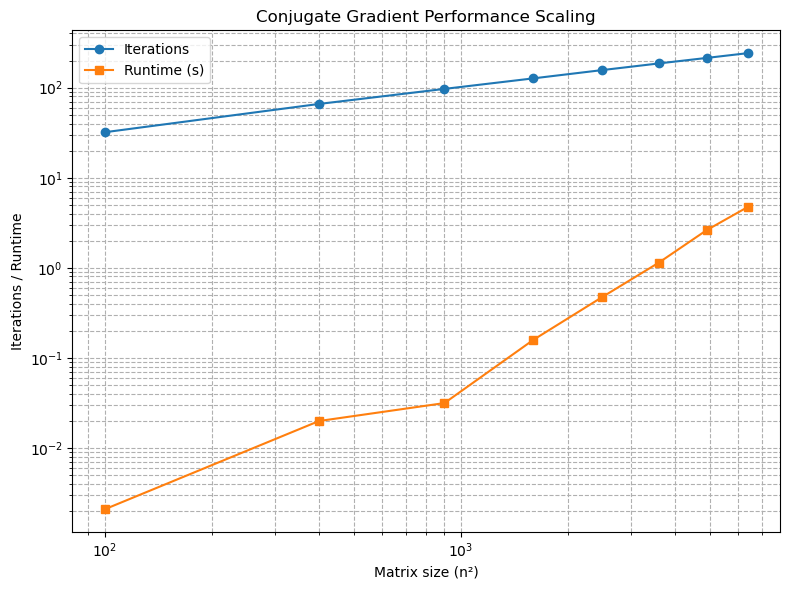

In [80]:
plt.figure(figsize=(8,6))
plt.loglog(n_values**2, iters, 'o-', label='Iterations')
plt.loglog(n_values**2, runtimes, 's-', label='Runtime (s)')
plt.xlabel('Matrix size (n²)')
plt.ylabel('Iterations / Runtime')
plt.title('Conjugate Gradient Performance Scaling')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.tight_layout()
plt.show()

As the matrix's size increases, so does the runtime and the number of iterations. However, the number of iterations, increases at a more steadier rate while runtintime increases much more sharply.